# scitex_seizure_metrics — Forecasting (alarm-based) Quick Start

Alarm-based metrics for seizure forecasting with an **explicit** `AlarmPolicy`. Every reproducibility knob (SPH / SOP / cadence / refractory / alarm threshold / FP-denominator) is mandatory — no silent defaults. The same probability stream that produces sample-based AUROC also produces alarm-based sensitivity / FP-per-hour / IoC, so the two regimes can be reported side-by-side.

**What this notebook covers**

1. Synthesise a 24-hour probability stream with three seizures and a pre-ictal ramp before each.
2. Visualise the stream with seizure markers + alarm threshold.
3. Pin a paper-equivalent `AlarmPolicy`, score with `forecasting.evaluate_stream` + a Poisson surrogate IoC test.
4. Threshold sweep — visualise the operating curve (sensitivity vs FP/hr).
5. Cadence ablation — visualise FP/hr and sensitivity as a function of cadence.

---
**figrecipe drop-in note** — this notebook uses `figrecipe.subplots()` instead of `matplotlib.pyplot.subplots()`. figrecipe returns a `RecordingFigure` + `RecordingAxes` pair that proxies every standard matplotlib method, so every line below is a verbatim copy of the matplotlib version — no API changes — but the figure can now also be saved as a reproducible bundle via `fg.save(fig, 'recipe.zip')`.

**Terminology** (the jargon used below; see the project README for the full glossary):

| Term | Meaning |
| --- | --- |
| **SPH** (`sph_seconds`) | *Seizure-Prediction Horizon* — minimum lead-time between an alarm firing and the seizure onset. Alarms that fire later than SPH before the seizure are not credited. |
| **SOP** (`sop_seconds`) | *Seizure-Occurrence Period* — the window after SPH during which the predicted seizure must actually occur for the alarm to count as a true positive. Defines `[SPH, SPH + SOP]`. |
| **Cadence** (`cadence_seconds`) | How often a fresh "is the warning on?" decision is emitted. |
| **Refractory** (`refractory_seconds`) | Post-alarm silent window that suppresses redundant alarms around a single seizure. |
| **FP/hr** | False-positive alarms per hour, normalised by `fp_denominator`: `'total'` recording time (Cook 2013, Karoly 2017) or `'interictal'`-only time (Mormann tradition). |
| **IoC** | *Improvement over Chance* — signed gap between the model's alarm-based sensitivity and a chance-baseline (Poisson surrogate by default). |
| **TIW** | *Time-In-Warning* — fraction of recording time the warning is active. The natural denominator that pairs with sensitivity in the Proix 2021 operating curve. |
| **AUROC / AUPRC / Brier / MCC / ECE** | Sample-based metrics (per-window classification). See `01_detection_quick_start.ipynb` and the README glossary. |


In [1]:
%matplotlib inline
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

import figrecipe as fg  # drop-in: returns RecordingFigure / RecordingAxes
import numpy as np

import scitex_seizure_metrics
from scitex_seizure_metrics import AlarmPolicy, forecasting

scitex_seizure_metrics.__version__

'0.1.0'

## 1. Synthetic 24-hour stream

Three seizures, 60-second cadence, a pre-ictal ramp from 60 min down to 10 min before each onset that lifts the predictor probability from ~0.1 noise floor up to ~0.7.

In [2]:
rng = np.random.default_rng(0)
duration = 24 * 3600
cadence = 60.0
times = np.arange(0, duration, cadence)
seizures = np.array([4 * 3600, 11 * 3600, 19 * 3600], dtype=float)

proba = rng.uniform(0, 0.3, size=times.size)
for sz in seizures:
    ramp_mask = (times >= sz - 3600) & (times < sz - 600)
    proba[ramp_mask] += np.linspace(0.1, 0.7, ramp_mask.sum())
proba = np.clip(proba, 0, 1)

print(f'samples           : {times.size}')
print(f'cadence (s)       : {cadence:.0f}')
print(f'seizures at hours : {[f"{s/3600:.1f}" for s in seizures]}')
print(f'mean proba        : {proba.mean():.3f}')

samples           : 1440
cadence (s)       : 60
seizures at hours : ['4.0', '11.0', '19.0']
mean proba        : 0.194


## 2. Visualise the stream

Pre-ictal ramps are visible as the three rising slopes; everything else is uniform noise. Vertical dashed lines mark the seizure onsets; horizontal dotted line is the alarm threshold.

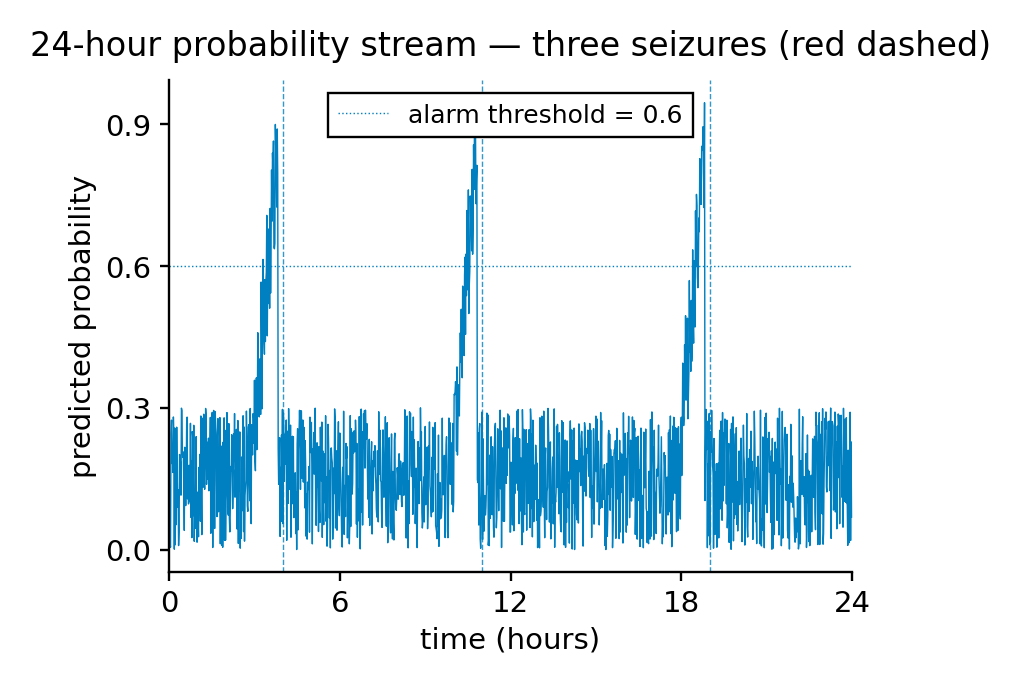

In [3]:
fig, ax = fg.subplots()
ax.plot(times / 3600, proba)
for sz in seizures:
    ax.axvline(sz / 3600, linestyle='--', alpha=0.8)
ax.axhline(0.6, linestyle=':', label='alarm threshold = 0.6')
ax.set_xlabel('time (hours)')
ax.set_ylabel('predicted probability')
ax.set_title('24-hour probability stream — three seizures (red dashed)')
ax.set_xlim(0, 24)
ax.legend()


## 3. AlarmPolicy + evaluate

Mormann's tradition uses `fp_denominator='interictal'` (FP/hr is normalised by interictal-only time). Set `'total'` to match Cook 2013 / Karoly 2017.

In [4]:
# A 0.6 threshold leaves the noise floor below the line and the
# pre-ictal ramps above it, but only inside the SPH-SOP window — try
# threshold 0.4 in the sweep cell below to see the operating point shift.
policy = AlarmPolicy(
    sph_seconds=300,
    sop_seconds=1800,           # wider SOP — covers the ramp
    cadence_seconds=60,
    refractory_seconds=600,
    alarm_threshold=0.4,
    fp_denominator='interictal',
)
rep = forecasting.evaluate_stream(
    proba, times, seizures, policy,
    total_recording_time=float(duration),
    n_surrogate=500,
)
print(f'sensitivity            : {rep.sensitivity:.3f}')
print(f'FP per hour            : {rep.fp_per_hour:.3f}')
print(f'IoC                    : {rep.ioc:.3f}')
print(f'surrogate sensitivity  : {rep.surrogate_sensitivity:.3f}')
print(f'time-in-warning        : {rep.time_in_warning_frac:.3f}')

sensitivity            : 0.000
FP per hour            : 0.241
IoC                    : -0.095
surrogate sensitivity  : 0.095
time-in-warning        : 0.076


## 4. Threshold sweep — operating curve

`sweep_thresholds` returns a DataFrame of (threshold, sensitivity, fp_per_hour, ioc, ...). Lower thresholds catch every seizure but flood with FPs; higher thresholds miss seizures.

In [5]:
df_thr = forecasting.sweep_thresholds(
    proba, times, seizures, policy,
    thresholds=np.linspace(0.1, 0.9, 17),
    total_recording_time=float(duration),
)
df_thr[['threshold', 'sensitivity', 'fp_per_hour', 'ioc', 'time_in_warning_frac']].round(3).head(10)

,threshold,sensitivity,fp_per_hour,ioc,time_in_warning_frac
0,0.10,0.667,4.867,-0.228,0.950
1,0.15,1.000,5.157,0.090,0.965
2,0.20,1.000,5.060,0.095,0.972
3,0.25,0.667,4.289,-0.197,0.949
4,0.30,0.000,0.289,-0.110,0.087
5,0.35,0.000,0.241,-0.092,0.077
6,0.40,0.000,0.241,-0.092,0.076
7,0.45,0.000,0.241,-0.092,0.076
8,0.50,0.667,0.193,0.557,0.083
9,0.55,1.000,0.193,0.873,0.092


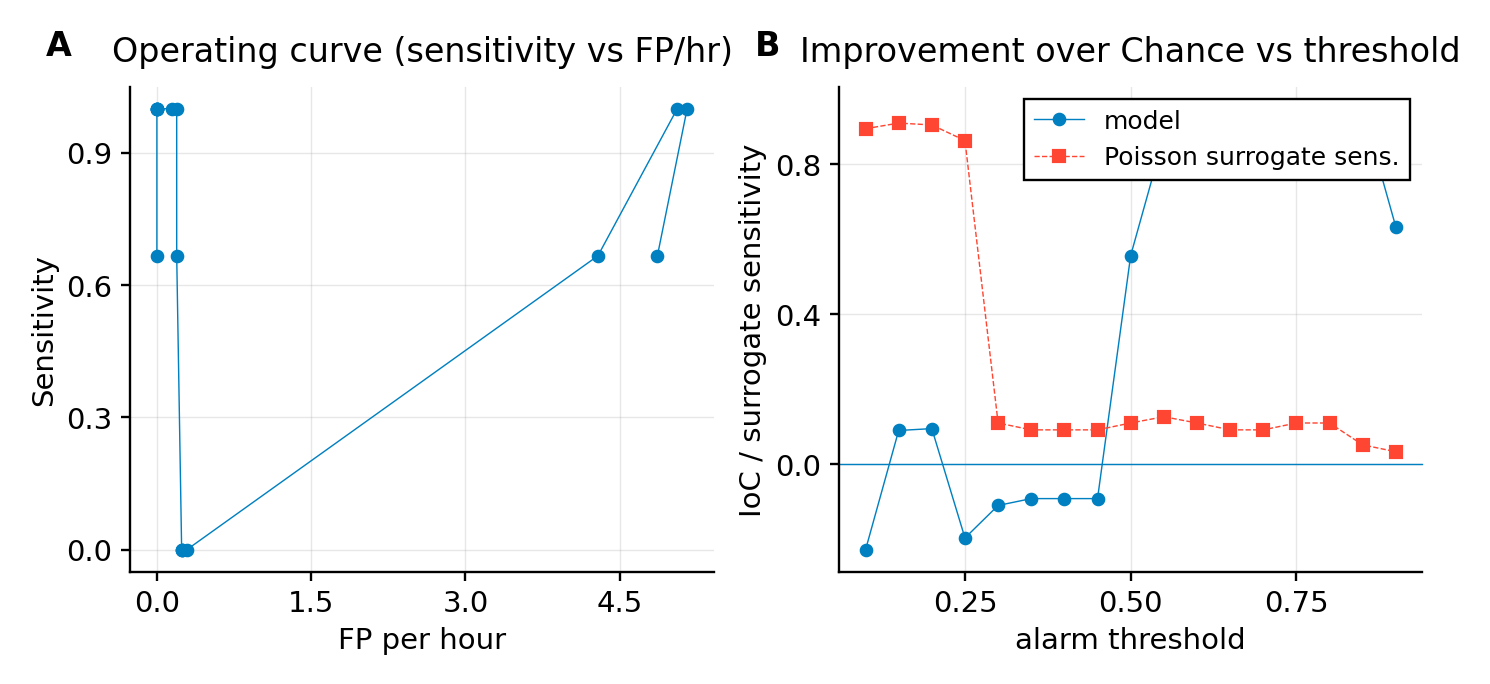

In [6]:
fig, axes = fg.subplots(1, 2)
axes[0].plot(df_thr['fp_per_hour'], df_thr['sensitivity'], 'o-')
axes[0].set_xlabel('FP per hour')
axes[0].set_ylabel('Sensitivity')
axes[0].set_title('Operating curve (sensitivity vs FP/hr)')
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_thr['threshold'], df_thr['ioc'], 'o-', label='model')
axes[1].plot(df_thr['threshold'], df_thr['surrogate_sensitivity'], 's--',
             label='Poisson surrogate sens.')
axes[1].axhline(0)
axes[1].set_xlabel('alarm threshold')
axes[1].set_ylabel('IoC / surrogate sensitivity')
axes[1].set_title('Improvement over Chance vs threshold')
axes[1].legend('upper right')
axes[1].grid(True, alpha=0.3)


## 5. Cadence ablation

Same predictor, varying alarm-evaluation cadence. Lower cadence = more potential FPs per hour at the same threshold (until the refractory window swallows them).

In [7]:
policies = [
    AlarmPolicy(
        sph_seconds=300, sop_seconds=1800,
        cadence_seconds=c, refractory_seconds=600,
        alarm_threshold=0.4, fp_denominator='interictal',
    )
    for c in [30, 60, 120, 300, 600]
]
df_cad = forecasting.sweep_policies(
    proba, times, seizures, policies,
    total_recording_time=float(duration),
)
df_cad[['cadence_s', 'sensitivity', 'fp_per_hour', 'ioc', 'time_in_warning_frac']].round(3)

,cadence_s,sensitivity,fp_per_hour,ioc,time_in_warning_frac
0,30,0.0,0.241,-0.092,0.076
1,60,0.0,0.241,-0.092,0.076
2,120,0.0,0.241,-0.092,0.076
3,300,0.0,0.241,-0.092,0.076
4,600,0.0,0.241,-0.092,0.076


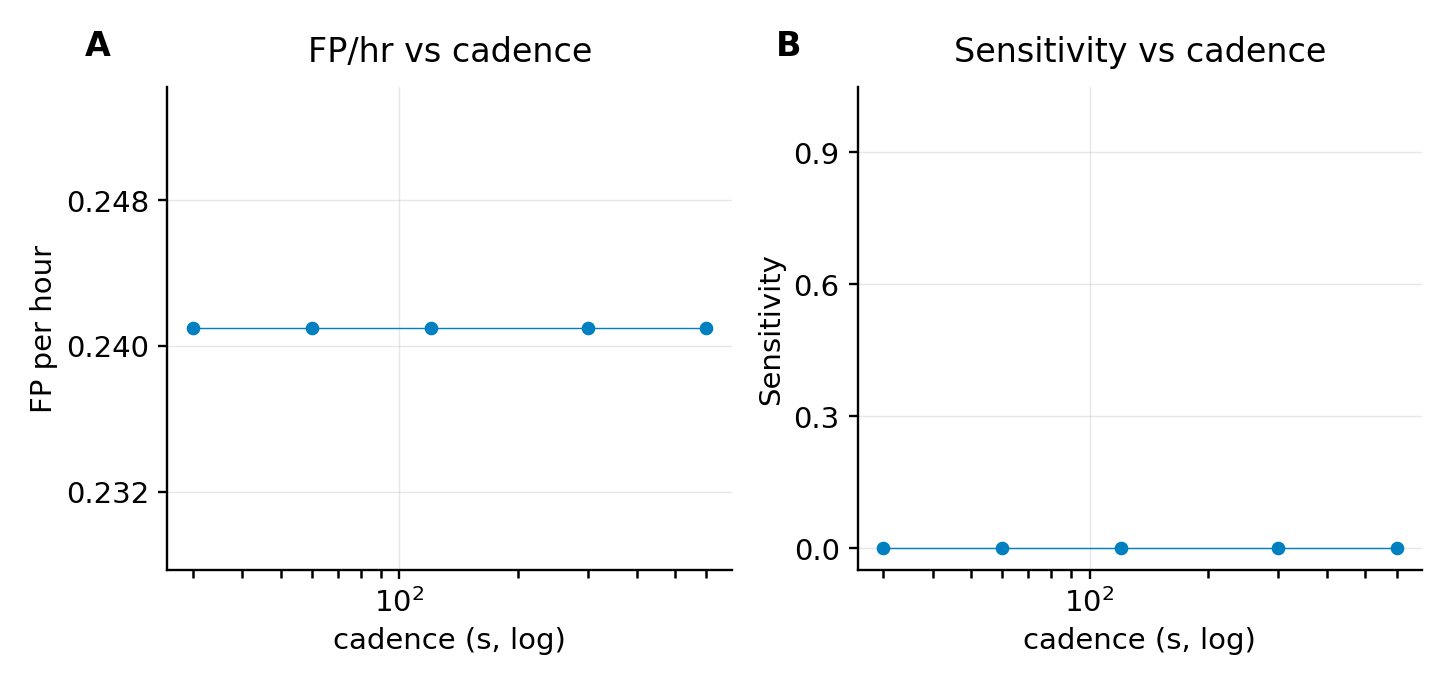

In [8]:
fig, axes = fg.subplots(1, 2)
axes[0].semilogx(df_cad['cadence_s'], df_cad['fp_per_hour'], 'o-')
axes[0].set_xlabel('cadence (s, log)')
axes[0].set_ylabel('FP per hour')
axes[0].set_title('FP/hr vs cadence')
axes[0].grid(True, alpha=0.3)
axes[1].semilogx(df_cad['cadence_s'], df_cad['sensitivity'], 'o-')
axes[1].set_xlabel('cadence (s, log)')
axes[1].set_ylabel('Sensitivity')
axes[1].set_title('Sensitivity vs cadence')
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, alpha=0.3)


## Where to next

- **`03_bridge_sample_to_alarm.ipynb`** — analytic bounds between regimes when only one was published.
- **`04_calibration.ipynb`** — Brier decomposition + reliability diagram.
- **`05_papers_andrade2024.ipynb`** — sample-vs-alarm regime gap, side-by-side panel.